# Linear Support Vector Machine (SVM) Model

In [ ]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

In [ ]:
iris = datasets.load_iris()

In [ ]:
X = iris["data"][:,(2, 3)] # petal length and petal width
y = (iris["target"] == 2).astype(np.float64) # Iris virginica

In [ ]:
svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC(C=1, loss="hinge")),
])

In [ ]:
svm_clf.fit(X, y)

In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(svm_clf, X, y, cv=5, scoring='accuracy', n_jobs=-1)

In [ ]:
#Create a set of predictions ot compare with the actual targets
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(svm_clf, X, y, cv=5, n_jobs=-1)

In [ ]:
#Create the confusion matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(y, y_pred)

In [ ]:
#Fine-tune SVM model with Grid Search
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"C": [1, 5, 10, 25, 50, 75, 100]},
]

svm_clf2 = LinearSVC(loss="hinge")

grid_search = GridSearchCV(svm_clf2, param_grid, cv=5,
                           scoring="accuracy",
                           return_train_score=True,
                           n_jobs=-1
                           )

grid_search.fit(X, y)

In [ ]:
svm_clf_better = LinearSVC(C=100, loss='hinge')
svm_clf_better.fit(X, y)

In [ ]:
cross_val_score(svm_clf_better, X, y, cv=5, scoring='accuracy', n_jobs=-1)

In [ ]:
y_pred_better = cross_val_predict(svm_clf_better, X, y, cv=5, n_jobs=-1)
confusion_matrix(y, y_pred_better)

# Nonlinear SVM Classification

In [ ]:
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

In [ ]:
X, y = make_moons(n_samples=100, noise=0.15)

In [ ]:
polynomial_svm_clf = Pipeline([
    ("poly_features", PolynomialFeatures(degree=3)),
    ("scaler", StandardScaler()),
    ("svm_clf", LinearSVC(C=10, loss="hinge"))
])

In [ ]:
polynomial_svm_clf.fit(X, y)

In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(polynomial_svm_clf, X, y, cv=5, scoring='accuracy', n_jobs=-1)

# Plots

In [11]:
import matplotlib.pyplot as plt
import numpy as np

In [12]:
def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r"$x_1$", fontsize=20)
    plt.ylabel(r"$x_2$", fontsize=20, rotation=0)

In [13]:
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)


In [ ]:
plot_predictions(polynomial_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.show()

# Polynomial Kernel

In [14]:
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [15]:
X, y = make_moons(n_samples=100, noise=0.15)

In [16]:
poly_kernel_clf1 = Pipeline([
    ("scaler", StandardScaler()),
    ("poly_kernel_svc", SVC(kernel="poly", degree=3, coef0=1, C=5))
])

In [17]:
poly_kernel_clf1.fit(X,y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('poly_kernel_svc', SVC(C=5, coef0=1, kernel='poly'))])

In [19]:
from sklearn.model_selection import cross_val_score

cross_val_score(poly_kernel_clf1, X, y, cv=5, scoring='accuracy', n_jobs=-1)

array([1.  , 0.95, 1.  , 0.95, 1.  ])

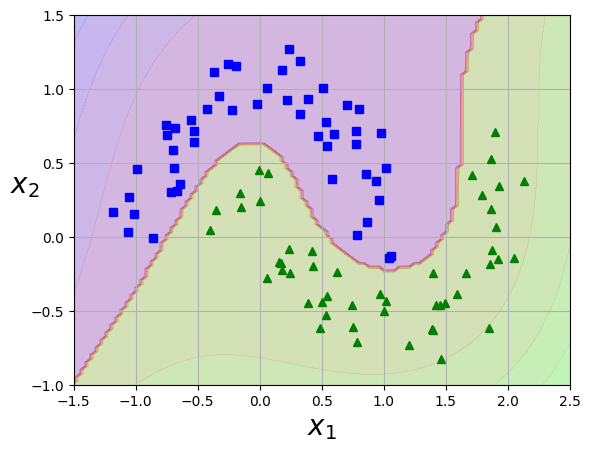

In [21]:
plot_predictions(poly_kernel_clf1, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.show()

In [22]:
#Fine-tune Polynomial Kernel model with Grid Search
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"degree": [1, 5, 10, 25], "coef0": [0, 0.5, 1, 2]},
]

poly_kernel = SVC(kernel="poly", C=5)

grid_search = GridSearchCV(poly_kernel, param_grid, cv=3,
                           scoring="accuracy",
                           return_train_score=True,
                           n_jobs=-1
                           )

grid_search.fit(X, y)

GridSearchCV(cv=3, estimator=SVC(C=5, kernel='poly'), n_jobs=-1,
             param_grid=[{'coef0': [0, 0.5, 1, 2], 'degree': [1, 5, 10, 25]}],
             return_train_score=True, scoring='accuracy')

In [23]:
poly_kernel_clf2 = Pipeline([
    ("scaler", StandardScaler()),
    ("poly_kernel_clf2", SVC(kernel="poly", degree=10, coef0=0.5, C=5))
])

In [24]:
poly_kernel_clf2.fit(X,y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('poly_kernel_clf2',
                 SVC(C=5, coef0=0.5, degree=10, kernel='poly'))])

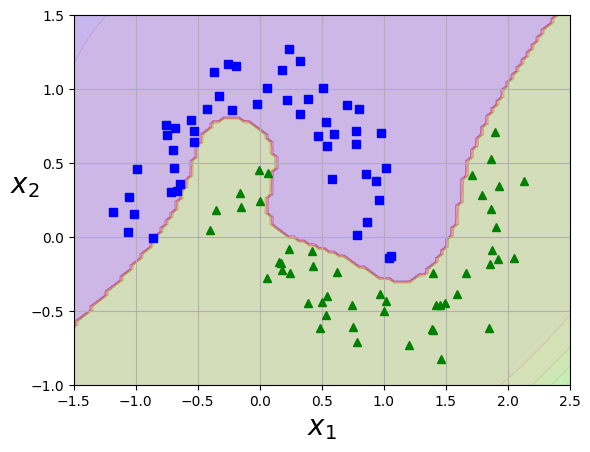

In [26]:
plot_predictions(poly_kernel_clf2, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.show()

In [27]:
cross_val_score(poly_kernel_clf2, X, y, cv=5, scoring='accuracy', n_jobs=-1)

array([1.  , 0.75, 0.95, 0.85, 1.  ])

# Gaussian RBF Kernel

In [28]:
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [29]:
X, y = make_moons(n_samples=100, noise=0.15)

In [30]:
rbf_kernel_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("rbf_kernel_clf", SVC(kernel="rbf", gamma=5, C=0.001))
])

In [31]:
rbf_kernel_clf.fit(X,y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('rbf_kernel_clf', SVC(C=0.001, gamma=5))])

In [32]:
cross_val_score(rbf_kernel_clf, X, y, cv=5, scoring='accuracy', n_jobs=-1)

array([0.95, 0.95, 0.95, 1.  , 1.  ])

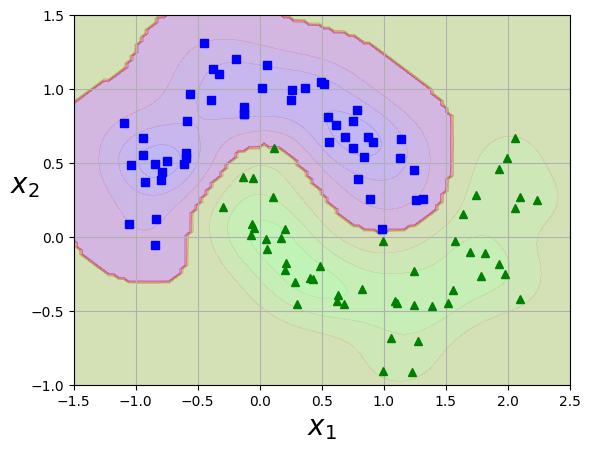

In [33]:
plot_predictions(rbf_kernel_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.show()